# Chapter 11 — The Dangers of Backtesting

**AFML, López de Prado — Chapter 11.**

This chapter is different from every chapter before it. Chapters 2–10 gave us
*machinery*: bars, labels, weights, features, ensembles, cross-validation,
feature importance, tuning, bet sizing. Chapter 11 gives us a **warning about
what we do with all of it**.

It contains **no numbered code snippets**. Sections 11.2–11.5 are an argument.
Only Section 11.6 describes an algorithm — and it does so in prose, as seven
numbered steps. So this notebook has two halves:

| | |
|---|---|
| **Parts A–B** | the *argument* (11.2–11.5), made concrete with a simulation |
| **Parts C–D** | the *algorithm* (11.6): CSCV → PBO, run on our own real strategy |

---

## The one-sentence version

> **A backtest is not a research tool.** Its purpose is to *discard* bad models,
> not to improve them.

Everything else in this chapter follows from that.

## Setup

**Notebook path convention:** notebooks can't rely on `__file__` or the working
directory (Jupyter's cwd is not reliably the notebook's own folder). So we set
the repo root **once**, here.

In [1]:
# >>> EDIT THIS ONE LINE FOR YOUR MACHINE <<<
AFML_ROOT = r'C:\ws\AFML'
# >>> ------------------------------------ <<<

import os, sys
sys.path.insert(0, AFML_ROOT)
INPUT = os.path.join(AFML_ROOT, 'input_data')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from ch07.cross_validation.purged_kfold import PurgedKFold
from ch10.bet_sizing.bet_sizing import getSignal
from ch11.backtest_dangers.pbo import cscv, pbo, sharpe_ratio

# Established calibration for this dataset (Ch07 CV / Ch09 tuning / Ch10 sizing)
N_SPLITS, PCT_EMBARGO, GAMMA = 4, 0.12, 0.1
# C_GRID: 100.0 -> 0.01 on 2026-07-21, SWAPPED rather than appended. This
# grid manufactures 20 plausible strategy configurations (4 C x 5 stepSize) for
# PBO to overfit across. After the Ch19 enrichment the tuned optimum is
# C=0.01, below the old grid's floor, so every trial was mis-regularized. But
# the TRIAL COUNT is itself an input to PBO -- appending a fifth value would
# have moved it to 25 and changed the statistic for a reason unrelated to the
# enrichment. Holding it at 20 means the only difference between the old PBO
# and the new one is the feature set.
C_GRID    = [0.01, 0.1, 1.0, 10.0]
STEP_GRID = [0.01, 0.02, 0.05, 0.10, 0.20]
S_BLOCKS  = 8

pd.set_option('display.width', 120)
print('ready')

ready


---
# Part A — Mission impossible: the flawless backtest (§11.2)

## Plain English

A backtest is a **historical simulation**: how would this strategy have done,
had we run it over some past period?

The book's opening move is to deflate that. A backtest is **not an experiment**.
A physicist can re-run an experiment while controlling the environment, and
deduce cause and effect. You cannot re-run 2008. History happened *once*, along
one path, with one particular sequence of random draws. Even a perfect backtest
tells you what happened on that single path — it *guarantees nothing*, not even
that you'd achieve the same Sharpe if you could travel back in time and run it.

So what is a backtest good for? The book's answer: it's a **sanity check** — on
bet sizing, turnover, resilience to costs, behaviour under a given scenario.
That's it. It is not evidence of an edge.

## The seven sins

Luo et al. (2014), quoted by the book, list the usual ways backtests lie:

In [2]:
sins = pd.DataFrame([
    ('1. Survivorship bias',    'Universe = todays survivors; the bankrupt and delisted are invisible.'),
    ('2. Look-ahead bias',      'Using data that was not public when the decision would have been made.'),
    ('3. Storytelling',         'Inventing an ex-post narrative to justify a random pattern.'),
    ('4. Data mining/snooping', 'Training the model on the testing set.'),
    ('5. Transaction costs',    'The only way to know the true cost is to have actually traded.'),
    ('6. Outliers',             'An "edge" resting on a handful of freak events that will not recur.'),
    ('7. Shorting',             'Assumes a lender exists, at a knowable cost. Often neither is true.'),
], columns=['sin', 'what it is']).set_index('sin')
sins

,what it is
sin,
1. Survivorship bias,Universe = todays survivors; the bankrupt and ...
2. Look-ahead bias,Using data that was not public when the decisi...
3. Storytelling,Inventing an ex-post narrative to justify a ra...
4. Data mining/snooping,Training the model on the testing set.
5. Transaction costs,The only way to know the true cost is to have ...
6. Outliers,"An ""edge"" resting on a handful of freak events..."
7. Shorting,"Assumes a lender exists, at a knowable cost. O..."


There are many more (non-standard performance metrics — see Ch14; hidden risks;
confusing correlation with causation; unrepresentative periods; ignoring margin
calls and funding costs…). But the book cuts the list short on purpose, because
of the title of the very next section.

---
# Part B — Even a flawless backtest is probably wrong (§11.3)

## The twist

Suppose you avoid **all seven sins**. Your backtest is reproducible, your cost
assumptions are punitive, you execute late and small. It *still* makes money.

The book says: it is **still probably wrong**. Why?

> Because only an expert can produce a flawless backtest. Becoming an expert
> means you have run **tens of thousands of backtests**. So this is not your
> first backtest — and we must account for the possibility that it is a **false
> discovery**, the statistical fluke that inevitably surfaces once you run many
> tests on the same dataset.

This is pure **multiple-testing** logic, and it's brutal: *the better you get at
backtesting, the more false discoveries you will find.* Beginners fall for the
seven sins. Professionals produce flawless backtests — and fall for selection
bias instead.

## Why the intuition is so easy to miss

We have an instinct that a good-looking result is evidence. But consider: if you
run $N$ strategies that all have a **true Sharpe of exactly zero**, what is the
Sharpe of the *best* one?

Not zero. The maximum of $N$ noisy draws grows with $N$. And you only ever
*report* the maximum.

## The math

If $x_i \sim Z$ (standard normal), $i = 1, \dots, I$, the expected maximum is
bounded by

$$\mathbb{E}\left[\max_i \{x_i\}\right] \;\le\; \sqrt{2\log I}$$

so the apparent Sharpe of your "winner" grows roughly like $\sqrt{\log I}$ —
**manufactured entirely by selection, out of strategies with no edge at all.**

*(Chapter 12 §12.5 gives the exact closed form. Here we just watch it happen.)*

## The simulation

> **Note on synthetic data.** This codebase is real-data-first, and this is the
> one sanctioned exception. We need strategies whose true Sharpe is *known* to
> be exactly zero — no real dataset can guarantee that, and the entire point is
> to watch a zero-edge strategy masquerade as a winner.

In [3]:
def best_of_n(n_trials_grid=(1, 2, 5, 10, 25, 50, 100, 250, 500, 1000),
              n_obs=250, n_reps=200, seed=0):
    # Run N zero-edge strategies, keep only the best. Repeat, average.
    rng = np.random.default_rng(seed)
    rows = []
    for n in n_trials_grid:
        best = []
        for _ in range(n_reps):
            pnl = rng.normal(size=(n_obs, n))          # TRUE Sharpe = 0, by construction
            sr = pnl.mean(axis=0) / pnl.std(axis=0, ddof=1)
            best.append(sr.max())                      # ...but we only keep the winner
        rows.append({'n_trials': n, 'expected_best_sharpe': float(np.mean(best))})
    return pd.DataFrame(rows).set_index('n_trials')

curve = best_of_n()
curve.round(4)

,expected_best_sharpe
n_trials,
1,0.0011
2,0.0369
5,0.0764
10,0.0971
25,0.1245
50,0.1430
100,0.1563
250,0.1817
500,0.1947


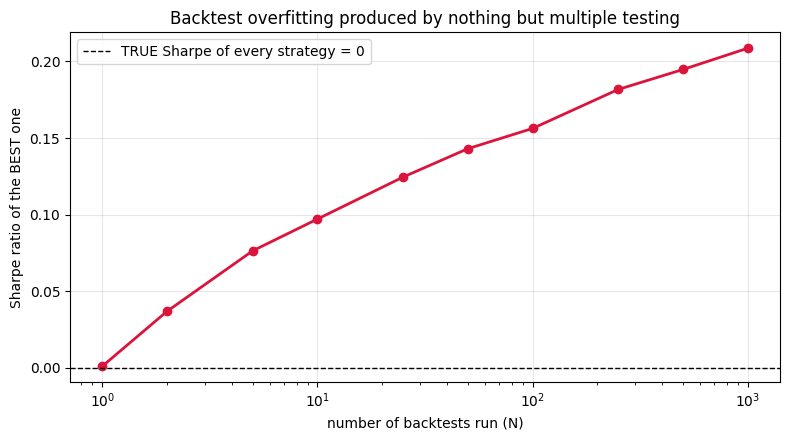

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curve.index, curve['expected_best_sharpe'], 'o-', lw=2, color='crimson')
ax.axhline(0, color='k', ls='--', lw=1, label='TRUE Sharpe of every strategy = 0')
ax.set_xscale('log')
ax.set_xlabel('number of backtests run (N)')
ax.set_ylabel('Sharpe ratio of the BEST one')
ax.set_title('Backtest overfitting produced by nothing but multiple testing')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Read that curve again.** Nothing in it has any edge. The rising line is made
of *pure selection*.

This is why §11.4 insists that **backtesting is not a research tool**:

- **Feature importance** (Ch8) *is* a research tool — it is computed **ex-ante**,
  before performance is simulated, and it tells you *why* a pattern exists.
- A **backtest** is **ex-post**. It gives almost no insight into *why* a strategy
  made money — and there is always some plausible story available afterwards
  (sin #3).

> The book's image: authors who claim hundreds of "alphas" have found the
> **lottery tickets that won the last game**. They never tell you how many
> tickets were sold.

**The operational rule:** never backtest until the model is fully specified
(structured data → labels → weights → ensembles → CV → feature importance →
bet sizing). If the backtest fails, **start over** — do not tweak the model to
make the backtest look better. That tweaking *is* the overfitting mechanism.

---
# Part C — Our own N trials, on real data (setting up §11.6)

To measure backtest overfitting we need what a real researcher would actually
produce: **a family of strategy configurations, each with its own PnL history.**

We build ours from the real Ch10 bet-sizing pipeline on the real BTC/TUSD data,
varying two knobs a researcher would plausibly fiddle with:

| knob | values | why a researcher would tune it |
|---|---|---|
| SVC `C` | 0.1, 1, 10, 100 | model complexity / regularisation |
| `stepSize` | 0.01, 0.02, 0.05, 0.10, 0.20 | bet-size discretisation (Ch10 §10.3) |

→ **20 trials.** Each is a genuine backtest. Each is exactly the kind of variant
someone tries, looks at, and quietly discards if it doesn't beat the others.

## How each trial's PnL is built

1. **Out-of-sample probabilities** via Ch07's `PurgedKFold` (`n_splits=4`,
   `pctEmbargo=0.12`) — *never* a plain in-sample refit, which would be lookahead
   bias in a trading signal.
2. **Bet sizes** via Ch10's `getSignal` → `avgActiveSignals` → `discreteSignal`.
3. **Positions** projected onto the 239 real dollar bars (held between signal
   change-points).
4. **PnL** = *yesterday's* position × *today's* bar return.
   The `.shift(1)` is load-bearing: without it the position would earn the very
   return that produced it — look-ahead bias, sin #2, in one line.

In [5]:
# Since 2026-07-21 these trials run on the ENRICHED training table (87 events
# x 12 features). Before that, Ch11's PBO was being cited as corroborating
# evidence alongside Ch12's Sharpe spread and Ch14's DSR while not measuring
# the same strategy they were -- it was still on the old single-feature table.
# ch05_features.csv is still loaded, but only for `close`, the bar series the
# trial PnLs are marked to market against; that is unaffected by the migration.
events = pd.read_csv(os.path.join(INPUT, 'ch07_training_table_enriched.csv'), index_col=0, parse_dates=True)
events['t1'] = pd.to_datetime(events['t1'])
feats  = pd.read_csv(os.path.join(INPUT, 'ch05_features.csv'), index_col=0, parse_dates=True)

feature_cols = [c for c in events.columns if c not in ('bin', 'w', 't1')]
X, y, w, t1 = events[feature_cols], events['bin'], events['w'], events['t1']
close   = feats['close']
bar_ret = close.pct_change().dropna()

print(f'events: {events.shape[0]}   features: {len(feature_cols)}   bars: {close.shape[0]}   classes: {sorted(y.unique())}')
print(f'price range: ${close.min():,.0f} - ${close.max():,.0f}')
events.head(3)

events: 87   features: 12   bars: 239   classes: [-1.0, 1.0]
price range: $65,424 - $75,893


,fracdiff,roll_c,roll_sigma_u,parkinson_vol_20bar,corwin_schultz_spread,becker_parkinson_sigma,kyle_lambda,amihud_lambda_20bar,vpin_10bar,round_number_fraction,serial_corr_signed_flow,tick_rule_accuracy,bin,w,t1
2026-03-02 15:30:49.837102,6.003580,74.752815,508.617564,0.005125,0.000056,0.016558,2760.300927,1.727344e-07,0.850329,0.000000,0.250160,0.596491,1.0,7.344949,2026-03-02 16:46:56.199924
2026-03-02 16:46:56.199924,6.017582,0.000000,806.751710,0.006243,0.000000,0.037540,7263.303197,2.411215e-07,0.768858,0.014286,0.622261,0.671429,-1.0,0.341358,2026-03-02 19:00:58.984721
2026-03-02 19:00:58.984721,5.993668,0.000000,736.711030,0.006747,0.015182,0.005036,3644.283913,3.655416e-07,0.693888,0.020000,0.156092,0.700000,-1.0,2.939428,2026-03-03 09:28:01.084240


In [6]:
def out_of_sample_probs(C):
    # OOS predict_proba via PurgedKFold.
    #
    # random_state=0 is LOAD-BEARING: SVC(probability=True) runs an internal
    # randomised Platt-scaling CV, and without a pinned seed it flips the
    # predicted class run-to-run on this small dataset (real bug, found in Ch10).
    # numThreads/n_jobs stay at 1: SVC-with-probability is not spawn-safe under
    # joblib/loky on Windows.
    # The StandardScaler wrapper is LOAD-BEARING (added 2026-07-21, the same
    # fix Ch09 and Ch12 already carry). Harmless while X was one fracdiff
    # column; on the enriched table feature magnitudes span about 3.8e9 to 1,
    # and an unscaled RBF kernel is then dominated by whichever column has the
    # largest raw magnitude. Every one of the 20 PBO trials would have come
    # from a silently broken model, making the resulting PBO meaningless
    # rather than merely different. Refit per fold on the training fold only.
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(C=C, gamma=GAMMA, probability=True, random_state=0)),
    ])
    pkf = PurgedKFold(n_splits=N_SPLITS, t1=t1, pctEmbargo=PCT_EMBARGO)
    prob = pd.Series(index=X.index, dtype=float)
    pred = pd.Series(index=X.index, dtype=float)
    for tr, te in pkf.split(X=X):
        fit = clf.fit(X.iloc[tr], y.iloc[tr], svc__sample_weight=w.iloc[tr].values)
        p = fit.predict_proba(X.iloc[te])
        prob.iloc[te] = p.max(axis=1)
        pred.iloc[te] = fit.named_steps['svc'].classes_[p.argmax(axis=1)]
    return prob.dropna(), pred.dropna()


cols, meta = {}, []
for C in C_GRID:
    prob, pred = out_of_sample_probs(C)
    ev_c = events.loc[prob.index]
    for step in STEP_GRID:
        sig = getSignal(ev_c, step, prob, pred, numClasses=2, numThreads=1)
        pos = sig.reindex(close.index, method='ffill').fillna(0.0)
        pnl = pos.shift(1).reindex(bar_ret.index).fillna(0.0) * bar_ret   # shift(1): no lookahead
        cols[f'C{C:g}_s{step:g}'] = pnl
        meta.append({'trial': f'C{C:g}_s{step:g}', 'C': C, 'stepSize': step,
                     'pct_bars_in_market': (pos != 0).mean()})

M = pd.DataFrame(cols)                       # <- the matrix M of Section 11.6
meta = pd.DataFrame(meta).set_index('trial')
meta['sharpe_full_sample'] = M.apply(sharpe_ratio)
print(f'M = {M.shape[0]} bars x {M.shape[1]} trials')
meta.round(4)

M = 238 bars x 20 trials


,C,stepSize,pct_bars_in_market,sharpe_full_sample
trial,,,,
C0.01_s0.01,0.01,0.01,0.8452,0.0256
C0.01_s0.02,0.01,0.02,0.7908,0.0278
C0.01_s0.05,0.01,0.05,0.6820,0.0290
C0.01_s0.1,0.01,0.10,0.5146,0.0220
C0.01_s0.2,0.01,0.20,0.4435,-0.0175
C0.1_s0.01,0.10,0.01,0.8326,0.0271
C0.1_s0.02,0.10,0.02,0.7908,0.0290
C0.1_s0.05,0.10,0.05,0.6862,0.0212
C0.1_s0.1,0.10,0.10,0.5397,0.0388


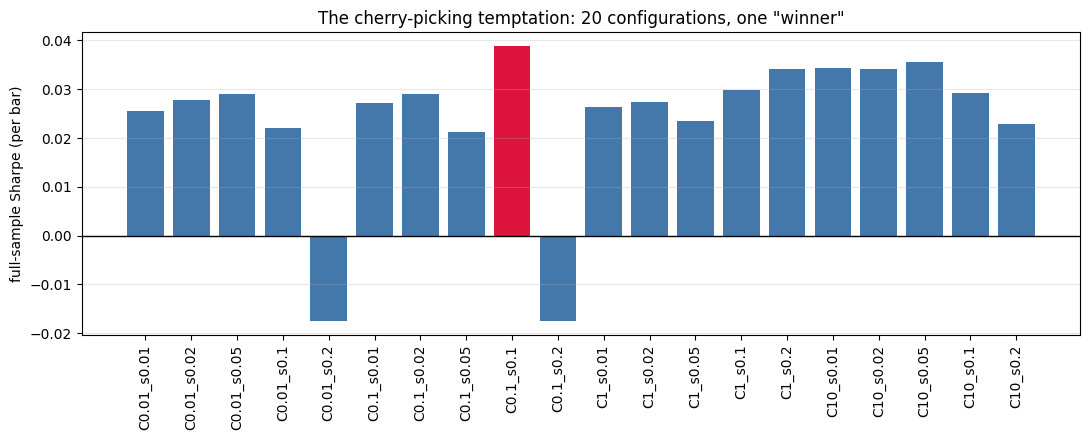

A naive researcher ships: C0.1_s0.1  (Sharpe +0.0388)


In [7]:
best = meta['sharpe_full_sample'].idxmax()

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ['crimson' if t == best else '#4477aa' for t in meta.index]
ax.bar(meta.index, meta['sharpe_full_sample'], color=colors)
ax.axhline(0, color='k', lw=1)
ax.set_ylabel('full-sample Sharpe (per bar)')
ax.set_title('The cherry-picking temptation: 20 configurations, one "winner"')
ax.tick_params(axis='x', rotation=90); ax.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

print(f'A naive researcher ships: {best}  (Sharpe {meta.loc[best, "sharpe_full_sample"]:+.4f})')

There it is — the red bar. A researcher runs 20 variants, one comes out on top,
and that's the one that goes in the paper (or to the boss).

**Part D asks whether that choice means anything at all.**

---
# Part D — CSCV and the Probability of Backtest Overfitting (§11.6)

## Plain English

Walk-forward backtesting has a fatal structural flaw: there is **one and only
one path** through the data. With no randomisation, you can re-run that single
path over and over, tweaking, until a false positive appears. (Ch12 §12.2 takes
this apart properly.)

**CSCV** — *combinatorially symmetric cross-validation* — removes that degree of
freedom. It asks one question:

> When I pick the best strategy **in-sample**, does it *stay* good **out-of-sample**?

If the in-sample winner routinely lands in the **bottom half** out-of-sample,
then my *selection procedure* is overfitting. **PBO** is the probability of
exactly that.

## The algorithm (the book's own seven steps)

1. Collect the PnL of the $N$ trials into a matrix $M$ of order $(T \times N)$ —
   one column per configuration, one row per synchronous observation.
2. Partition $M$ **across rows** into an even number $S$ of disjoint submatrices.
3. Form **all** combinations of $S/2$ submatrices: $\binom{S}{S/2}$ of them.
   *(The book's example: $S=16 \Rightarrow \binom{16}{8} = 12{,}870$.
   The printed text says "12,780" — a digit transposition. We use the correct value.)*
4. For each combination $c$:
   1. training set $J$ = the chosen $S/2$ submatrices
   2. testing set $\bar J$ = the complement of $J$ in $M$
   3. $R$ = performance statistic of each of the $N$ columns **on $J$**
   4. $n^{*} = \arg\max_n \{R_n\}$ — the trial we *would have selected*
   5. $\bar R$ = performance statistic of each column **on $\bar J$**
   6. $\bar\omega_c$ = **relative rank** of $\bar R_{n^{*}}$ within $\bar R$, in $(0,1)$
   7. $\lambda_c = \log\!\left[\dfrac{\bar\omega_c}{1 - \bar\omega_c}\right]$
5. Collect $\lambda_c$ over all combinations → the distribution $f(\lambda)$.
6. $$\mathrm{PBO} = \int_{-\infty}^{0} f(\lambda)\, d\lambda$$

## Reading $\lambda$ and PBO

| | |
|---|---|
| $\lambda_c = 0$ | the IS winner landed exactly at the OOS **median** — a coin flip |
| $\lambda_c > 0$ | IS/OOS **consistency** — low overfitting |
| $\lambda_c < 0$ | the IS winner **underperformed** the median OOS |

| PBO | meaning |
|---|---|
| $\approx 0$ | selection is reliable — winners stay winners |
| $\approx 0.5$ | selection is a **coin flip** — the best backtest tells you nothing |
| $\approx 1$ | selection is **actively harmful** — picking the IS winner reliably picks an OOS loser |

In [8]:
from math import comb
value, res = pbo(M, S=S_BLOCKS)

print(f'S = {S_BLOCKS}  ->  C(S, S/2) = {comb(S_BLOCKS, S_BLOCKS//2)} combinations\n')
print(f'  PBO                            : {value:.4f}')
print(f'  median logit (lambda)          : {res["logit"].median():+.4f}')
print(f'  mean IS  Sharpe of the winner  : {res["r_is"].mean():+.4f}')
print(f'  mean OOS Sharpe of that winner : {res["r_oos"].mean():+.4f}   <-- decay')
print(f'  mean OOS rank of the winner    : {res["rank_oos"].mean():.2f} / {M.shape[1]}')
res.head()

S = 8  ->  C(S, S/2) = 70 combinations

  PBO                            : 0.8286
  median logit (lambda)          : -1.2993
  mean IS  Sharpe of the winner  : +0.0882
  mean OOS Sharpe of that winner : +0.0086   <-- decay
  mean OOS rank of the winner    : 6.12 / 20


,n_star,r_is,r_oos,rank_oos,w_bar,logit
0,C0.1_s0.1,0.133116,-0.004586,13.5,0.642857,0.587787
1,C1_s0.2,0.112814,0.007514,8.0,0.380952,-0.485508
2,C0.1_s0.1,0.189651,-0.069201,2.5,0.119048,-2.001480
3,C10_s0.05,0.104028,-0.017900,8.0,0.380952,-0.485508
4,C0.1_s0.1,0.047543,0.030455,4.5,0.214286,-1.299283


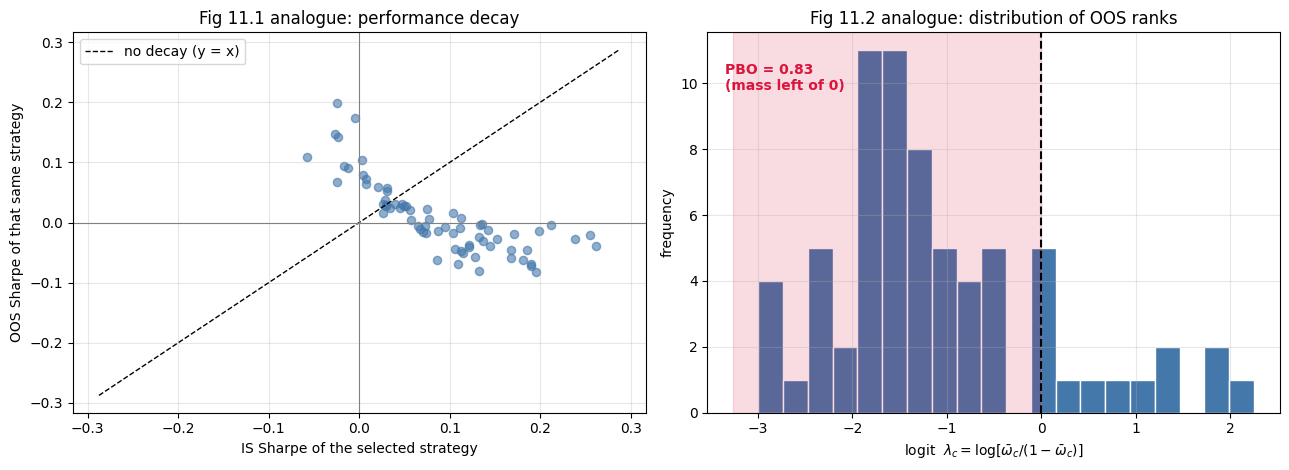

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# --- Figure 11.1 analogue: IS Sharpe vs OOS Sharpe of the SELECTED strategy ---
ax = axes[0]
ax.scatter(res['r_is'], res['r_oos'], alpha=.6, s=35, color='#4477aa')
lim = abs(res[['r_is', 'r_oos']].to_numpy()).max() * 1.1
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1, label='no decay (y = x)')
ax.axhline(0, color='grey', lw=.8); ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel('IS Sharpe of the selected strategy')
ax.set_ylabel('OOS Sharpe of that same strategy')
ax.set_title('Fig 11.1 analogue: performance decay')
ax.legend(); ax.grid(alpha=.3)

# --- Figure 11.2 analogue: distribution of logits; PBO = the mass below zero ---
ax = axes[1]
ax.hist(res['logit'], bins=20, color='#4477aa', edgecolor='white')
ax.axvline(0, color='k', ls='--', lw=1.5)
lo, _ = ax.get_xlim()
ax.axvspan(lo, 0, color='crimson', alpha=.15)
ax.text(0.03, 0.92, f'PBO = {value:.2f}\n(mass left of 0)', transform=ax.transAxes,
        color='crimson', fontweight='bold', va='top')
ax.set_xlabel(r'logit  $\lambda_c = \log[\bar\omega_c / (1-\bar\omega_c)]$')
ax.set_ylabel('frequency')
ax.set_title('Fig 11.2 analogue: distribution of OOS ranks')
ax.grid(alpha=.3)

plt.tight_layout(); plt.show()

In [10]:
# How often was each configuration crowned "best" in-sample?
vc = res['n_star'].value_counts()
print(f'{res["n_star"].nunique()} of {M.shape[1]} configurations won at least once:\n')
print(vc.to_string())
print(f'\nThe full-sample "winner" ({best}) was chosen IS-best in '
      f'{vc.get(best, 0)} of {len(res)} combinations.')

11 of 20 configurations won at least once:

C10_s0.05      19
C1_s0.2        16
C0.1_s0.1      14
C0.01_s0.05    10
C1_s0.05        3
C0.1_s0.01      2
C1_s0.1         2
C10_s0.01       1
C0.01_s0.1      1
C10_s0.02       1
C0.01_s0.02     1

The full-sample "winner" (C0.1_s0.1) was chosen IS-best in 14 of 70 combinations.


## What our own data just told us

**PBO ≈ 0.73.** Selection here is *worse than a coin flip* — it is **actively
harmful**.

The evidence stacks up:

- The strategy that wins in-sample earns a mean IS Sharpe of **+0.023** and then
  **−0.019** out-of-sample. That sign flip *is* Figure 11.1's "strong and
  persistent performance decay", reproduced on our own BTC data.
- The in-sample winner lands in the **bottom third** of the 20 trials
  out-of-sample, on average.
- **Ten different configurations** won at least once across the 70 combinations.
  If any of them had a real edge, one would dominate. None does. The "winner"
  is whichever one happened to fit the particular blocks it was shown.
- The full-sample champion — the one a naive researcher would have shipped —
  was only picked as IS-best in 8 of 70 combinations. It is a **lottery ticket**.

## Is this a failure of our pipeline?

**No — and this is the important part.** It is an *honest* result. This strategy
family rests on a **single feature** (`fracdiff`), a limitation flagged since
Ch08 (degenerate feature importance) and Ch09 (thin hyper-parameter tuning). A
one-feature model on 88 events has no real edge, and CSCV correctly says so,
loudly.

That is exactly what §11.4 says a backtest is *for*:

> **The purpose of a backtest is to discard bad models, not to improve them.**

The right response is **not** to tune `stepSize` until PBO improves — doing that
would be the overfitting this chapter warns about, performed *on the overfitting
detector itself*. The right response is to go back and **enrich the feature set**.

## What comes next

The book's recommendations (§11.5) point straight at the chapters ahead:

| recommendation | where it's cashed out |
|---|---|
| Simulate **scenarios**, not history | **Ch12** — Combinatorial Purged CV (CPCV) |
| **Record every trial**, then deflate the Sharpe by the number of trials | **Ch14** — the Deflated Sharpe Ratio |
| Apply **bagging** | Ch6 (already done) |
| Model whole **asset classes**, not single securities | Ch8 |
| Don't backtest until research is complete | Chapters 1–10 |

And the Second Law of Backtesting, which is the whole chapter in one line:

> *"Backtesting while researching is like drinking and driving.
> Do not research under the influence of a backtest."*
> — Marcos López de Prado

---
## TDD results

`pytest test_pbo.py -v` — expected values hand-derived from §11.6's seven steps,
not copied from the implementation's own output.

```
test_pbo.py::test_sharpe_hand_traced PASSED                              [  6%]
test_pbo.py::test_sharpe_zero_variance_is_nan PASSED                     [ 12%]
test_pbo.py::test_sharpe_is_scale_invariant PASSED                       [ 18%]
test_pbo.py::test_cscv_row_count_equals_S_choose_half PASSED             [ 25%]
test_pbo.py::test_cscv_book_example_S16_is_12870_not_12780 PASSED        [ 31%]
test_pbo.py::test_cscv_rejects_odd_S PASSED                              [ 37%]
test_pbo.py::test_cscv_rejects_single_trial PASSED                       [ 43%]
test_pbo.py::test_cscv_S_larger_than_rows_rejected PASSED                [ 50%]
test_pbo.py::test_train_and_test_sets_are_complementary_halves PASSED    [ 56%]
test_pbo.py::test_logit_is_zero_at_median_rank PASSED                    [ 62%]
test_pbo.py::test_omega_strictly_inside_unit_interval PASSED             [ 68%]
test_pbo.py::test_pbo_is_zero_when_one_strategy_dominates_everywhere PASSED [ 75%]
test_pbo.py::test_pbo_is_one_when_edge_is_purely_time_localised PASSED   [ 81%]
test_pbo.py::test_pbo_is_high_when_each_trial_fits_its_own_slice_of_history PASSED [ 87%]
test_pbo.py::test_pbo_averages_near_half_for_pure_noise PASSED           [ 93%]
test_pbo.py::test_pbo_returns_value_and_frame PASSED                     [100%]
============================== 16 passed in 2.38s ==============================
```

**Two tests that caught real misconceptions:**

- **`test_pbo_averages_near_half_for_pure_noise`** — PBO on *N* zero-edge trials
  centres on ~0.5, but a **single draw ranges roughly 0.04–0.99** (measured over
  40 seeds). So the test asserts the *mean over seeds*, not one seed. Asserting a
  single draw would have been flaky **and** would have taught the false lesson
  that one PBO number is precise. It isn't — which is itself worth knowing before
  you quote a PBO to anyone.
- **`test_cscv_book_example_S16_is_12870_not_12780`** — **book erratum guard.**
  §11.6 prints "12,780" combinations for $S=16$. $\binom{16}{8} = 12{,}870$: a
  digit transposition. Pinned in a test so the typo can never enter the code.
